# ECG Image Classification with HOG + Random Forest

This notebook builds a complete four-class ECG image-classification workflow using:

- **Histogram of Oriented Gradients (HOG)** for feature extraction
- **Random Forest** for multiclass classification
- **scikit-learn** for evaluation
- **OpenCV** for image preprocessing
- **KaggleHub** for dataset access

### Classes
1. Myocardial Infarction
2. History of Myocardial Infarction
3. Abnormal Heartbeat
4. Normal

The workflow includes exploratory visualization, robust preprocessing, model training, confusion-matrix analysis, per-class metrics, multiclass ROC-AUC analysis, bootstrap accuracy intervals, model export, and single-image inference.

> **Research / educational use only.** This notebook is not a clinically validated diagnostic system.

## 1. Install dependencies

This cell installs the libraries required in a fresh Google Colab environment.

In [1]:
%pip install -q kagglehub opencv-python scikit-image scikit-learn matplotlib seaborn pandas joblib tqdm

## 2. Imports and reproducibility settings

In [2]:
from pathlib import Path
import json
import random
import warnings

import cv2
import joblib
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from tqdm.auto import tqdm
from skimage.feature import hog

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

IMG_SIZE = 128
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

HOG_PARAMS = {
    "orientations": 9,
    "pixels_per_cell": (8, 8),
    "cells_per_block": (2, 2),
    "block_norm": "L2-Hys",
}

RF_PARAMS = {
    "n_estimators": 1000,
    "max_depth": 4,
    "class_weight": "balanced",
    "random_state": SEED,
    "n_jobs": -1,
}

OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Configuration ready.")

Configuration ready.


## 3. Download and locate the ECG image dataset

The notebook uses the Kaggle dataset:

`kanishkarathore1604/ecg-image`

In [3]:
dataset_root = Path(
    kagglehub.dataset_download("kanishkarathore1604/ecg-image")
)

data_root = dataset_root / "ECG_DATA"
train_dir = data_root / "train"
test_dir = data_root / "test"

if not train_dir.is_dir() or not test_dir.is_dir():
    raise FileNotFoundError(
        f"Expected ECG_DATA/train and ECG_DATA/test under {dataset_root}"
    )

categories = sorted(p.name for p in train_dir.iterdir() if p.is_dir())
test_categories = sorted(p.name for p in test_dir.iterdir() if p.is_dir())

if categories != test_categories:
    raise RuntimeError(
        "Training and test class folders do not match.\n"
        f"Train: {categories}\nTest: {test_categories}"
    )

print("Dataset root:", dataset_root)
print("\nDiscovered classes:")
for i, class_name in enumerate(categories):
    print(f"{i}: {class_name}")

100%|██████████| 826M/826M [00:10<00:00, 81.0MB/s]

Extracting files...


Dataset root: /root/.cache/kagglehub/datasets/kanishkarathore1604/ecg-image/versions/1

Discovered classes:
0: ECG Images of Myocardial Infarction Patients (240x12=2880)
1: ECG Images of Patient that have History of MI (172x12=2064)
2: ECG Images of Patient that have abnormal heartbeat (233x12=2796)
3: Normal Person ECG Images (284x12=3408)


## 4. Clean display labels and class distribution

The folder names are kept internally so labels remain aligned with the dataset.
Shorter names are used only for plots and reports.

,Train,Test
Myocardial Infarction,956,239
History of MI,516,172
Abnormal Heartbeat,699,233
Normal,852,284


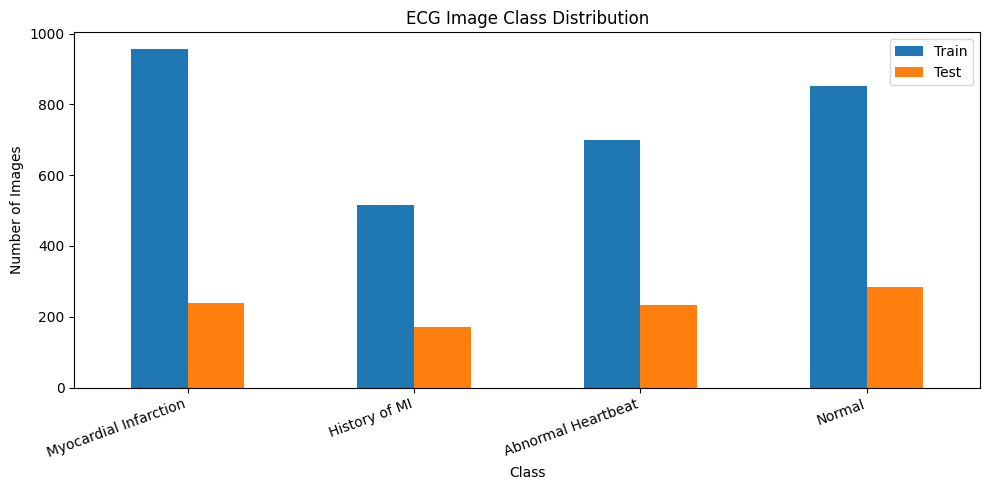

In [4]:
def clean_class_name(name: str) -> str:
    lower = name.lower()
    if "history of mi" in lower:
        return "History of MI"
    if "myocardial infarction" in lower:
        return "Myocardial Infarction"
    if "abnormal heartbeat" in lower:
        return "Abnormal Heartbeat"
    if "normal person" in lower:
        return "Normal"
    return name

display_names = [clean_class_name(name) for name in categories]
class_to_index = {name: i for i, name in enumerate(categories)}

def count_images(split_dir: Path) -> dict:
    counts = {}
    for class_name in categories:
        class_dir = split_dir / class_name
        counts[clean_class_name(class_name)] = sum(
            1 for p in class_dir.iterdir()
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        )
    return counts

train_counts = count_images(train_dir)
test_counts = count_images(test_dir)

counts_df = pd.DataFrame({
    "Train": pd.Series(train_counts),
    "Test": pd.Series(test_counts),
})

display(counts_df)

ax = counts_df.plot(kind="bar", figsize=(10, 5))
ax.set_title("ECG Image Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 5. Inspect representative ECG images

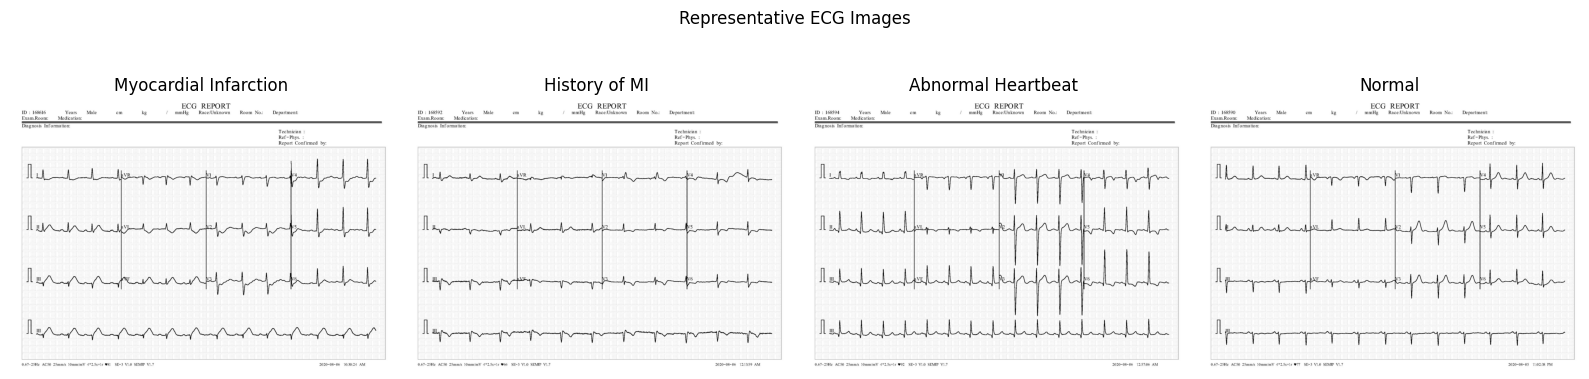

In [5]:
fig, axes = plt.subplots(1, len(categories), figsize=(16, 4))

for ax, class_name, display_name in zip(axes, categories, display_names):
    candidates = sorted(
        p for p in (train_dir / class_name).iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )
    if not candidates:
        ax.axis("off")
        continue

    image = cv2.imread(str(candidates[0]), cv2.IMREAD_GRAYSCALE)
    ax.imshow(image, cmap="gray")
    ax.set_title(display_name)
    ax.axis("off")

plt.suptitle("Representative ECG Images", y=1.02)
plt.tight_layout()
plt.show()

## 6. HOG feature extraction

Each image is:

1. loaded in grayscale,
2. resized to **128 × 128** pixels,
3. converted into a HOG feature vector.

The HOG configuration uses **9 orientations**, **8 × 8 pixels per cell**, **2 × 2 cells per block**, and **L2-Hys normalization**.

In [6]:
def read_grayscale_image(image_path: Path, image_size: int = IMG_SIZE) -> np.ndarray:
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"OpenCV could not read: {image_path}")
    return cv2.resize(
        image,
        (image_size, image_size),
        interpolation=cv2.INTER_AREA,
    )

def extract_hog_features(
    image_path: Path,
    image_size: int = IMG_SIZE,
    visualize: bool = False,
):
    image = read_grayscale_image(image_path, image_size=image_size)

    result = hog(
        image,
        orientations=HOG_PARAMS["orientations"],
        pixels_per_cell=HOG_PARAMS["pixels_per_cell"],
        cells_per_block=HOG_PARAMS["cells_per_block"],
        block_norm=HOG_PARAMS["block_norm"],
        visualize=visualize,
        feature_vector=True,
    )

    if visualize:
        features, hog_image = result
        return features.astype(np.float32), hog_image

    return result.astype(np.float32)

### Visualize HOG on one ECG image

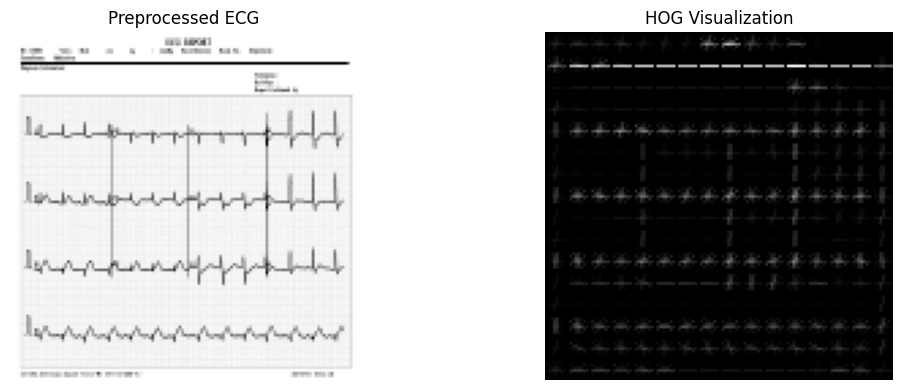

HOG feature dimensions: 8100


In [7]:
example_class = categories[0]
example_path = next(
    p for p in sorted((train_dir / example_class).iterdir())
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
)

example_image = read_grayscale_image(example_path)
example_features, example_hog = extract_hog_features(example_path, visualize=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(example_image, cmap="gray")
axes[0].set_title("Preprocessed ECG")
axes[0].axis("off")

axes[1].imshow(example_hog, cmap="gray")
axes[1].set_title("HOG Visualization")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("HOG feature dimensions:", example_features.shape[0])

## 7. Build training and test feature matrices

Unreadable files are reported rather than silently ignored.

In [8]:
def iter_image_files(folder: Path):
    return [
        p for p in sorted(folder.iterdir())
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

def load_split(split_dir: Path):
    features = []
    labels = []
    skipped = []

    for class_index, class_name in enumerate(categories):
        image_paths = iter_image_files(split_dir / class_name)

        for image_path in tqdm(
            image_paths,
            desc=f"{split_dir.name}: {clean_class_name(class_name)}",
            leave=False,
        ):
            try:
                feature_vector = extract_hog_features(image_path)
            except (ValueError, cv2.error) as exc:
                skipped.append((str(image_path), str(exc)))
                continue

            features.append(feature_vector)
            labels.append(class_index)

    X = np.asarray(features, dtype=np.float32)
    y = np.asarray(labels, dtype=np.int64)
    return X, y, skipped

X_train, y_train, skipped_train = load_split(train_dir)
X_test, y_test, skipped_test = load_split(test_dir)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)
print("Skipped training files:", len(skipped_train))
print("Skipped test files:", len(skipped_test))

train: Myocardial Infarction:   0%|          | 0/956 [00:00<?, ?it/s]

train: History of MI:   0%|          | 0/516 [00:00<?, ?it/s]

train: Abnormal Heartbeat:   0%|          | 0/699 [00:00<?, ?it/s]

train: Normal:   0%|          | 0/852 [00:00<?, ?it/s]

test: Myocardial Infarction:   0%|          | 0/239 [00:00<?, ?it/s]

test: History of MI:   0%|          | 0/172 [00:00<?, ?it/s]

test: Abnormal Heartbeat:   0%|          | 0/233 [00:00<?, ?it/s]

test: Normal:   0%|          | 0/284 [00:00<?, ?it/s]

X_train: (3023, 8100)
y_train: (3023,)
X_test : (928, 8100)
y_test : (928,)
Skipped training files: 0
Skipped test files: 0


## 8. Train the Random Forest classifier

The classifier uses 1,000 trees, a maximum tree depth of 4, class balancing, and a fixed random seed.

In [9]:
rf_model = RandomForestClassifier(**RF_PARAMS)

rf_model.fit(X_train, y_train)

print("Training complete.")

Training complete.


## 9. Evaluate the model

In [10]:
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

report_dict = classification_report(
    y_test,
    y_pred,
    target_names=display_names,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report_dict).T

print(f"Accuracy          : {accuracy:.4f}")
print(f"Balanced accuracy : {balanced_accuracy:.4f}")
print(f"Macro F1          : {macro_f1:.4f}")
print(f"Weighted F1       : {weighted_f1:.4f}")

display(report_df.round(4))

Accuracy          : 0.9494
Balanced accuracy : 0.9427
Macro F1          : 0.9460
Weighted F1       : 0.9492


,precision,recall,f1-score,support
Myocardial Infarction,1.0000,1.0000,1.0000,239.0000
History of MI,0.9259,0.8721,0.8982,172.0000
Abnormal Heartbeat,0.9643,0.9270,0.9453,233.0000
Normal,0.9109,0.9718,0.9404,284.0000
accuracy,0.9494,0.9494,0.9494,0.9494
macro avg,0.9503,0.9427,0.9460,928.0000
weighted avg,0.9500,0.9494,0.9492,928.0000


### Confusion matrix

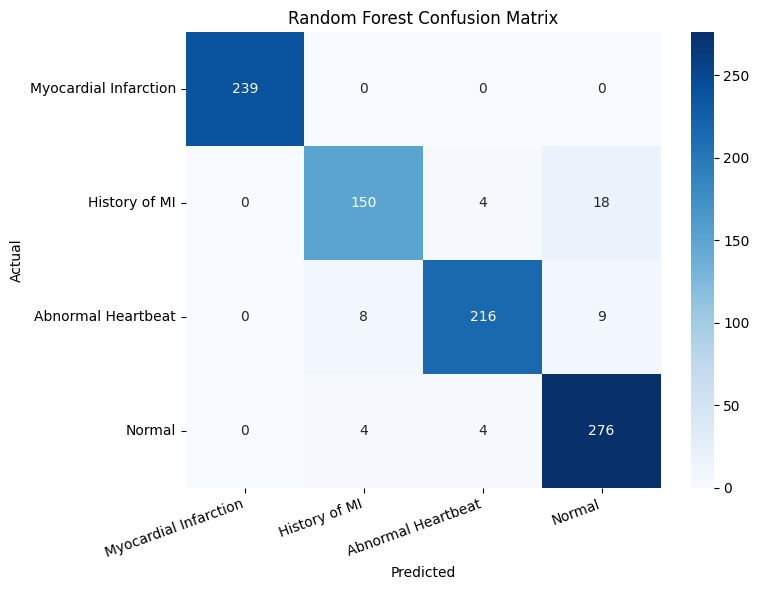

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=display_names,
    yticklabels=display_names,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.xticks(rotation=20, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

### Per-class precision, recall, and F1-score

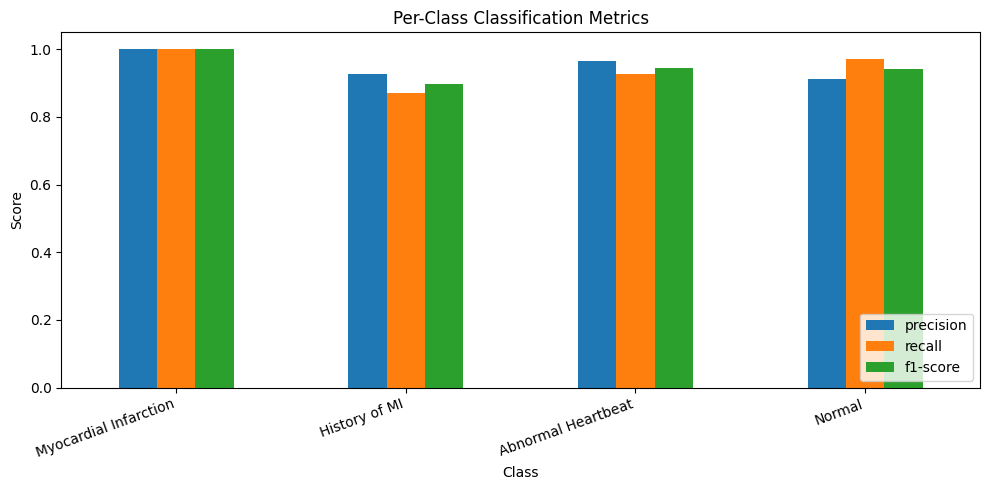

In [12]:
per_class_df = report_df.loc[display_names, ["precision", "recall", "f1-score"]]

ax = per_class_df.plot(kind="bar", figsize=(10, 5), ylim=(0, 1.05))
ax.set_title("Per-Class Classification Metrics")
ax.set_ylabel("Score")
ax.set_xlabel("Class")
plt.xticks(rotation=20, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "per_class_metrics.png", dpi=200, bbox_inches="tight")
plt.show()

## 10. Multiclass ROC-AUC analysis

One-vs-rest ROC curves provide an additional view of class separability.

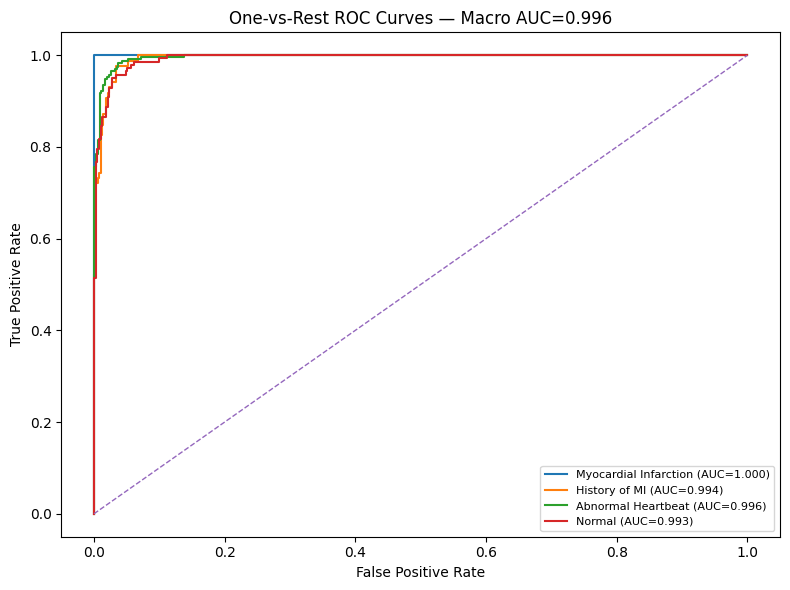

Macro one-vs-rest ROC-AUC: 0.9958


In [13]:
y_test_bin = label_binarize(y_test, classes=np.arange(len(categories)))

roc_auc_macro = roc_auc_score(
    y_test_bin,
    y_proba,
    average="macro",
    multi_class="ovr",
)

plt.figure(figsize=(8, 6))

for class_index, display_name in enumerate(display_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, class_index], y_proba[:, class_index])
    class_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{display_name} (AUC={class_auc:.3f})")

plt.plot([0, 1], [0, 1], "--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"One-vs-Rest ROC Curves — Macro AUC={roc_auc_macro:.3f}")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curves.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Macro one-vs-rest ROC-AUC: {roc_auc_macro:.4f}")

## 11. Bootstrap confidence interval for test accuracy

This interval resamples **test images**, not patients. If multiple images originate from the same patient, image-level resampling can overstate effective sample independence.

In [14]:
def bootstrap_accuracy_ci(
    y_true,
    y_predicted,
    n_bootstrap=2000,
    confidence=0.95,
    seed=SEED,
):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_predicted = np.asarray(y_predicted)

    scores = []
    n = len(y_true)

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        scores.append(
            accuracy_score(y_true[idx], y_predicted[idx])
        )

    alpha = 1 - confidence
    lower = np.quantile(scores, alpha / 2)
    upper = np.quantile(scores, 1 - alpha / 2)

    return float(lower), float(upper)

acc_ci_low, acc_ci_high = bootstrap_accuracy_ci(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Image-level bootstrap 95% CI: [{acc_ci_low:.4f}, {acc_ci_high:.4f}]")

Accuracy: 0.9494
Image-level bootstrap 95% CI: [0.9343, 0.9634]


## 12. Save metrics and model bundle

The model is stored together with the class names and HOG preprocessing configuration so inference uses the same settings as training.

In [15]:
metrics = {
    "n_train": int(len(y_train)),
    "n_test": int(len(y_test)),
    "hog_feature_dimensions": int(X_train.shape[1]),
    "accuracy": float(accuracy),
    "balanced_accuracy": float(balanced_accuracy),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "macro_ovr_roc_auc": float(roc_auc_macro),
    "accuracy_bootstrap_ci_95_image_level": [
        float(acc_ci_low),
        float(acc_ci_high),
    ],
    "classification_report": report_dict,
    "confusion_matrix": cm.tolist(),
    "random_forest": RF_PARAMS,
    "hog": {
        "image_size": IMG_SIZE,
        "orientations": HOG_PARAMS["orientations"],
        "pixels_per_cell": list(HOG_PARAMS["pixels_per_cell"]),
        "cells_per_block": list(HOG_PARAMS["cells_per_block"]),
        "block_norm": HOG_PARAMS["block_norm"],
    },
    "classes": categories,
    "display_names": display_names,
}

with open(OUTPUT_DIR / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

model_bundle = {
    "model": rf_model,
    "classes": categories,
    "display_names": display_names,
    "image_size": IMG_SIZE,
    "hog_params": HOG_PARAMS,
}

joblib.dump(model_bundle, "rf_ecg_model.joblib")

print("Saved:")
print("-", OUTPUT_DIR / "metrics.json")
print("-", OUTPUT_DIR / "confusion_matrix.png")
print("-", OUTPUT_DIR / "per_class_metrics.png")
print("-", OUTPUT_DIR / "roc_curves.png")
print("- rf_ecg_model.joblib")

Saved:
- results/metrics.json
- results/confusion_matrix.png
- results/per_class_metrics.png
- results/roc_curves.png
- rf_ecg_model.joblib


## 13. Inference on a new ECG image

In [16]:
def extract_hog_from_array(
    gray_image: np.ndarray,
    image_size: int,
    hog_params: dict,
) -> np.ndarray:
    resized = cv2.resize(
        gray_image,
        (image_size, image_size),
        interpolation=cv2.INTER_AREA,
    )

    return hog(
        resized,
        orientations=hog_params["orientations"],
        pixels_per_cell=tuple(hog_params["pixels_per_cell"]),
        cells_per_block=tuple(hog_params["cells_per_block"]),
        block_norm=hog_params["block_norm"],
        visualize=False,
        feature_vector=True,
    ).astype(np.float32)

def predict_ecg_image(
    image_path,
    model_path="rf_ecg_model.joblib",
):
    bundle = joblib.load(model_path)

    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    features = extract_hog_from_array(
        image,
        image_size=bundle["image_size"],
        hog_params=bundle["hog_params"],
    ).reshape(1, -1)

    model = bundle["model"]
    pred_index = int(model.predict(features)[0])
    probabilities = model.predict_proba(features)[0]

    result = pd.DataFrame({
        "Class": bundle["display_names"],
        "Probability": probabilities,
    }).sort_values("Probability", ascending=False)

    print("Predicted class:", bundle["display_names"][pred_index])
    display(result.style.format({"Probability": "{:.2%}"}))

    plt.figure(figsize=(12, 4))
    plt.imshow(image, cmap="gray")
    plt.title(f"Prediction: {bundle['display_names'][pred_index]}")
    plt.axis("off")
    plt.show()

    return result

### Optional: upload an ECG image in Google Colab

In [ ]:
try:
    from google.colab import files

    uploaded = files.upload()

    for filename in uploaded:
        predict_ecg_image(filename)

except ImportError:
    print(
        "Google Colab upload helper is unavailable. "
        "Call predict_ecg_image('/path/to/image.png') instead."
    )